# Notebook 06: EDA Impacto Laboral, Demanda de Tratamiento y Policonsumo

**Objetivos de este notebook:**
1. Analizar la demanda de tratamiento (Capítulo Q) e identificar las principales sustancias que motivan a las personas a buscar ayuda.
2. Evaluar el impacto laboral del consumo: accidentes laborales, ausentismo y percepción de disminución del rendimiento (Capítulo R).
3. Crear un índice de policonsumo para medir cuántas sustancias ilegales diferentes consume una persona.
4. Explorar las intersecciones: ¿El policonsumo aumenta la probabilidad de sufrir un accidente laboral o necesitar tratamiento?

**Nota metodológica:** Todos los cálculos y porcentajes están ponderados utilizando el factor de expansión `fex_c` para representar con precisión a la población colombiana.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [16]:
# Definir rutas
BASE_DIR = Path('..')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cargar el DataFrame maestro
df = pd.read_parquet(PROCESSED_DIR / 'df_master.parquet')
df['fex_c'] = pd.to_numeric(df['fex_c'], errors='coerce').fillna(0)

# Variables de consumo en los últimos 12 meses usadas por el índice de policonsumo.
dicc_si_no = {1: 1, 2: 0}
for columna_original, columna_nueva in {
    'k_03': 'marihuana_12m',
    'l_02': 'cocaina_12m',
    'm_02': 'basuco_12m',
    'n_02': 'extasis_12m'
}.items():
    if columna_original in df.columns:
        df[columna_nueva] = df[columna_original].map(dicc_si_no).fillna(0)
    else:
        df[columna_nueva] = 0

def porcentaje_ponderado(df, condicion):
    """
    Calcula el porcentaje ponderado de una condición booleana.
    condicion: Una serie booleana de pandas (True/False).
    """
    total_pob = df['fex_c'].sum()
    pob_positiva = df.loc[condicion, 'fex_c'].sum()
    return (pob_positiva / total_pob) * 100

print(f"Datos cargados. Población representada: {df['fex_c'].sum():,.0f} personas.")

Datos cargados. Población representada: 23,747,363 personas.


In [17]:
# Mapeo de respuestas donde 1 = Si, 2 = No. 9 se trata como No responde / No aplica.
dicc_si_no = {1: 1, 2: 0}

# Q_01: En los últimos 12 meses, ¿sintió la necesidad de recibir ayuda para dejar de consumir?
if 'q_01_a' in df.columns:
    df['tratamiento_necesidad_tabaco'] = df['q_01_a'].map(dicc_si_no).fillna(0)
if 'q_01_b' in df.columns:
    df['tratamiento_necesidad_alcohol'] = df['q_01_b'].map(dicc_si_no).fillna(0)
if 'q_01_c' in df.columns:
    df['tratamiento_necesidad_otras'] = df['q_01_c'].map(dicc_si_no).fillna(0)

# Q_02: ¿Buscó ayuda especializada para disminuir el consumo?
if 'q_02' in df.columns:
    df['tratamiento_busqueda_ayuda'] = df['q_02'].map(dicc_si_no).fillna(0)

# Q_03: ¿Está o estuvo en tratamiento?
# 1=Actualmente, 2=En los últimos 12 meses, 3=Hace más de 12 meses, 4=Nunca.
# Creamos un indicador binario: 1 si está actualmente o en los últimos 12 meses.
if 'q_03' in df.columns:
    df['tratamiento_activo_reciente'] = df['q_03'].isin([1, 2]).astype(int)

# Q_04: Sustancia principal que motivó el tratamiento
# 1=Alcohol, 2=Marihuana, 3=Cocaína, 4=Basuco, 5=Heroína, 6=Otra, 9=NS
dicc_sust_tratamiento = {
    1: 'Alcohol', 2: 'Marihuana', 3: 'Cocaína',
    4: 'Basuco', 5: 'Heroína', 6: 'Otra'
}
if 'q_04' in df.columns:
    df['sustancia_principal_tratamiento'] = df['q_04'].map(dicc_sust_tratamiento).fillna('No especificado')

print("Variables de demanda de tratamiento creadas.")

Variables de demanda de tratamiento creadas.


In [18]:
# R_01: ¿Ha tenido algún accidente o incidente laboral en los últimos 12 meses?
if 'r_01' in df.columns:
    df['accidente_laboral'] = df['r_01'].map(dicc_si_no).fillna(0)

# R_02: En las 12 horas anteriores al accidente, ¿había consumido alcohol u otras sustancias?
if 'r_02' in df.columns:
    df['accidente_bajo_efecto'] = df['r_02'].map(dicc_si_no).fillna(0)
    # Solo es válido para personas que realmente tuvieron un accidente.
    df['accidente_bajo_efecto'] = df['accidente_bajo_efecto'] * df['accidente_laboral']

# R_03: Número de días completos de ausencia por enfermedad o accidente (últimos 30 días).
if 'r_03' in df.columns:
    df['dias_ausentismo'] = pd.to_numeric(df['r_03'], errors='coerce').fillna(0)
    # Limitar a 30 días para eliminar valores inválidos (ej. 98, 99).
    df['dias_ausentismo'] = df['dias_ausentismo'].clip(upper=30)

# R_04: ¿Esta ausencia fue consecuencia del consumo de alcohol o sustancias?
if 'r_04' in df.columns:
    df['ausentismo_por_sustancias'] = df['r_04'].map(dicc_si_no).fillna(0)
    # Solo es válido para personas que realmente faltaron al trabajo (R_03 > 0).
    df['ausentismo_por_sustancias'] = df['ausentismo_por_sustancias'] * (df['dias_ausentismo'] > 0).astype(int)

# R_09: ¿Considera que su rendimiento laboral ha disminuido por el consumo?
if 'r_09' in df.columns:
    df['bajo_rendimiento_laboral'] = df['r_09'].map(dicc_si_no).fillna(0)

print("Variables de impacto laboral creadas.")

Variables de impacto laboral creadas.


In [19]:
# Lista de sustancias ilegales (prevalencia de 12 meses) creadas en el Notebook 05.
sustancias = ['marihuana_12m', 'cocaina_12m', 'basuco_12m', 'extasis_12m']

# Contar cuántas de estas sustancias consumió la persona.
df['num_sustancias_ilegales'] = df[sustancias].sum(axis=1)

# Crear una variable categórica para el policonsumo.
condiciones = [
    df['num_sustancias_ilegales'] == 0,
    df['num_sustancias_ilegales'] == 1,
    df['num_sustancias_ilegales'] == 2,
    df['num_sustancias_ilegales'] >= 3
]
etiquetas = ['0 (Sin consumo ilegal)', '1 sustancia', '2 sustancias', '3+ sustancias']
df['categoria_policonsumo'] = np.select(condiciones, etiquetas, default='Otro')

print("Índice de policonsumo creado.")

Índice de policonsumo creado.


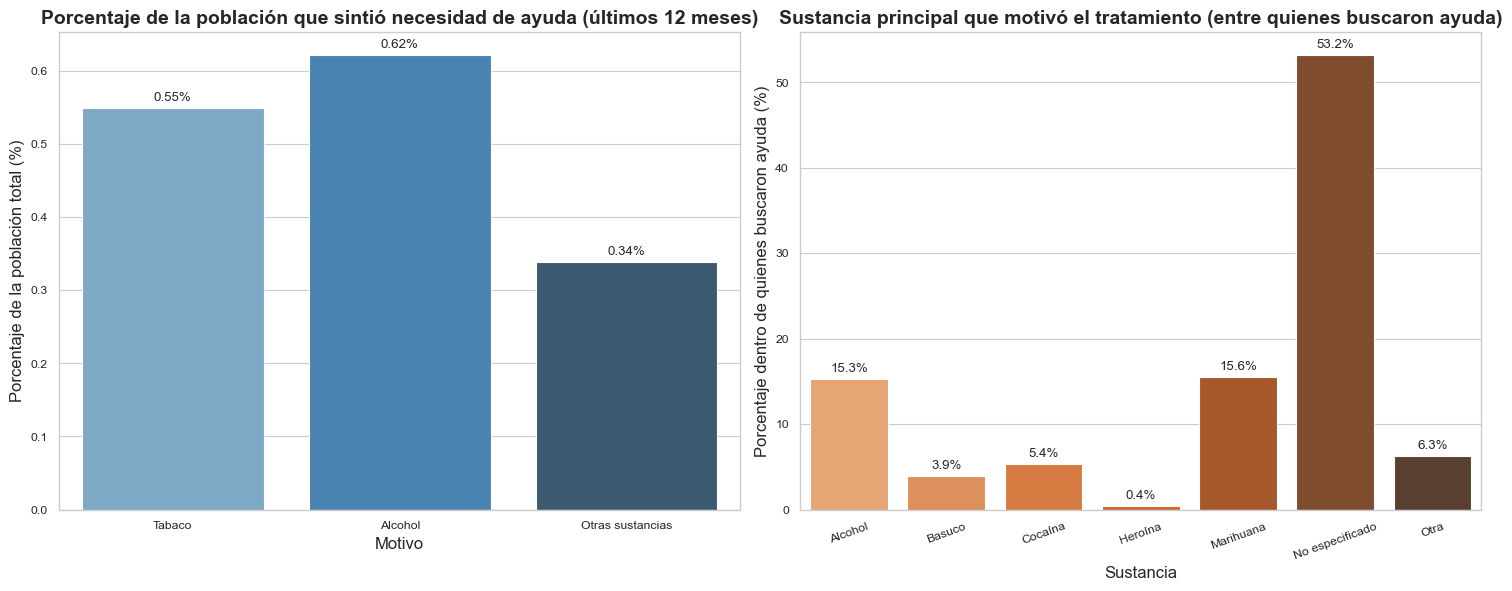

In [20]:
# Calcular porcentajes ponderados de necesidad de tratamiento.
data_tratamiento = {
    'Motivo': ['Tabaco', 'Alcohol', 'Otras sustancias'],
    'Necesidad_ayuda': [
        porcentaje_ponderado(df, df['tratamiento_necesidad_tabaco'] == 1),
        porcentaje_ponderado(df, df['tratamiento_necesidad_alcohol'] == 1),
        porcentaje_ponderado(df, df['tratamiento_necesidad_otras'] == 1)
    ]
}
df_tratamiento = pd.DataFrame(data_tratamiento)

# Sustancia principal para tratamiento entre quienes buscaron ayuda.
df_ayuda = df[df['tratamiento_busqueda_ayuda'] == 1]
if not df_ayuda.empty:
    resumen_sust_ayuda = df_ayuda.groupby('sustancia_principal_tratamiento')['fex_c'].sum().reset_index()
    resumen_sust_ayuda.columns = ['Sustancia', 'Poblacion']
    resumen_sust_ayuda['Porcentaje'] = (resumen_sust_ayuda['Poblacion'] / resumen_sust_ayuda['Poblacion'].sum()) * 100

    # Gráfico 1: Necesidad de ayuda
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax1 = axes[0]
    sns.barplot(data=df_tratamiento, x='Motivo', y='Necesidad_ayuda', ax=ax1, palette='Blues_d')
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.2f%%', padding=3)
    ax1.set_title('Porcentaje de la población que sintió necesidad de ayuda (últimos 12 meses)', fontweight='bold')
    ax1.set_ylabel('Porcentaje de la población total (%)')

    ax2 = axes[1]
    sns.barplot(data=resumen_sust_ayuda, x='Sustancia', y='Porcentaje', ax=ax2, palette='Oranges_d')
    for container in ax2.containers:
        ax2.bar_label(container, fmt='%.1f%%', padding=3)
    ax2.set_title('Sustancia principal que motivó el tratamiento (entre quienes buscaron ayuda)', fontweight='bold')
    ax2.set_ylabel('Porcentaje dentro de quienes buscaron ayuda (%)')
    ax2.tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_tratamiento_demanda.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No hay datos disponibles para demanda de tratamiento.")

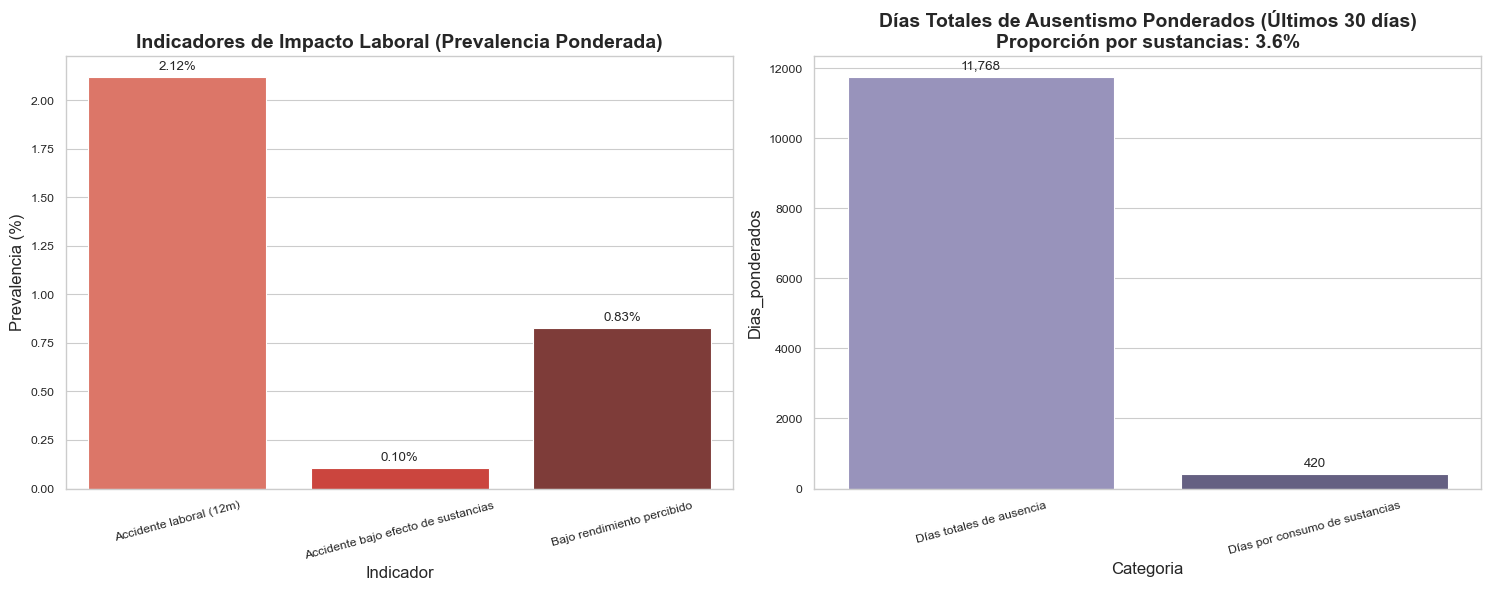

Días promedio de ausentismo (ponderado): 0.23 días.


In [21]:
# Calcular indicadores laborales clave.
data_labor = {
    'Indicador': [
        'Accidente laboral (12m)',
        'Accidente bajo efecto de sustancias',
        'Bajo rendimiento percibido'
    ],
    'Prevalencia (%)': [
        porcentaje_ponderado(df, df['accidente_laboral'] == 1),
        porcentaje_ponderado(df, df['accidente_bajo_efecto'] == 1),
        porcentaje_ponderado(df, df['bajo_rendimiento_laboral'] == 1)
    ]
}
df_labor = pd.DataFrame(data_labor)

# Calcular ausentismo: días promedio y proporción debida a sustancias.
absent_total_pop = df['dias_ausentismo'].sum()
if absent_total_pop > 0:
    avg_absent_days = np.average(df['dias_ausentismo'], weights=df['fex_c'])
else:
    avg_absent_days = 0

# Proporción de días de ausentismo causados por sustancias.
absent_substance = (df['dias_ausentismo'] * df['ausentismo_por_sustancias']).sum()
if absent_total_pop > 0:
    prop_absent_substance = (absent_substance / absent_total_pop) * 100
else:
    prop_absent_substance = 0

# Graficar indicadores laborales.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
sns.barplot(data=df_labor, x='Indicador', y='Prevalencia (%)', ax=ax1, palette='Reds_d')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f%%', padding=3)
ax1.set_title('Indicadores de Impacto Laboral (Prevalencia Ponderada)', fontweight='bold')
ax1.tick_params(axis='x', rotation=15)

ax2 = axes[1]
data_absent = {
    'Categoria': ['Días totales de ausencia', 'Días por consumo de sustancias'],
    'Dias_ponderados': [absent_total_pop, absent_substance]
}
df_absent = pd.DataFrame(data_absent)
sns.barplot(data=df_absent, x='Categoria', y='Dias_ponderados', ax=ax2, palette='Purples_d')
for container in ax2.containers:
    ax2.bar_label(container, fmt='{:,.0f}', padding=3)
ax2.set_title(f'Días Totales de Ausentismo Ponderados (Últimos 30 días)\nProporción por sustancias: {prop_absent_substance:.1f}%', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_impacto_laboral.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Días promedio de ausentismo (ponderado): {avg_absent_days:.2f} días.")

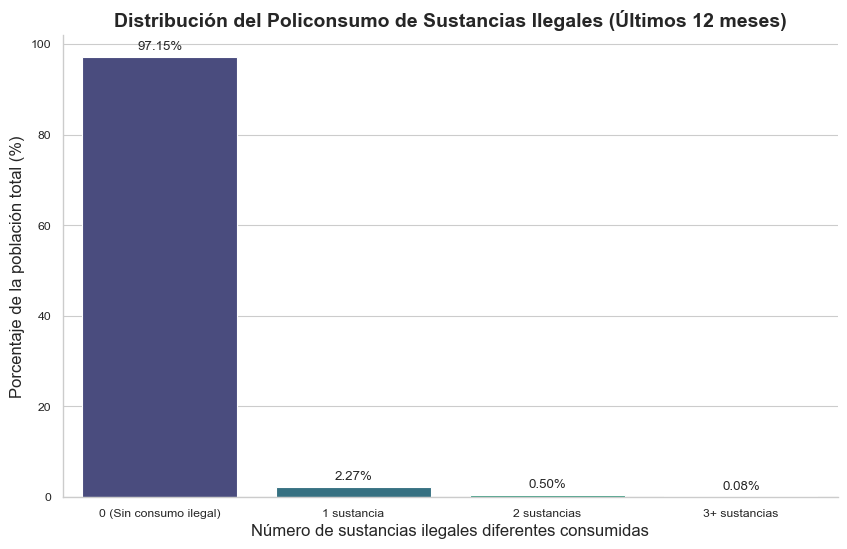

In [22]:
# Distribución ponderada de las categorías de policonsumo.
resumen_poli = df.groupby('categoria_policonsumo')['fex_c'].sum().reset_index()
resumen_poli.columns = ['Categoria', 'Poblacion']
resumen_poli['Porcentaje'] = (resumen_poli['Poblacion'] / resumen_poli['Poblacion'].sum()) * 100
resumen_poli = resumen_poli.sort_values('Categoria')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=resumen_poli, x='Categoria', y='Porcentaje', palette='viridis')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)
plt.title('Distribución del Policonsumo de Sustancias Ilegales (Últimos 12 meses)', fontweight='bold')
plt.xlabel('Número de sustancias ilegales diferentes consumidas')
plt.ylabel('Porcentaje de la población total (%)')
sns.despine()

plt.savefig(FIGURES_DIR / "13_distribucion_policonsumo.png", dpi=300, bbox_inches='tight')
plt.show()

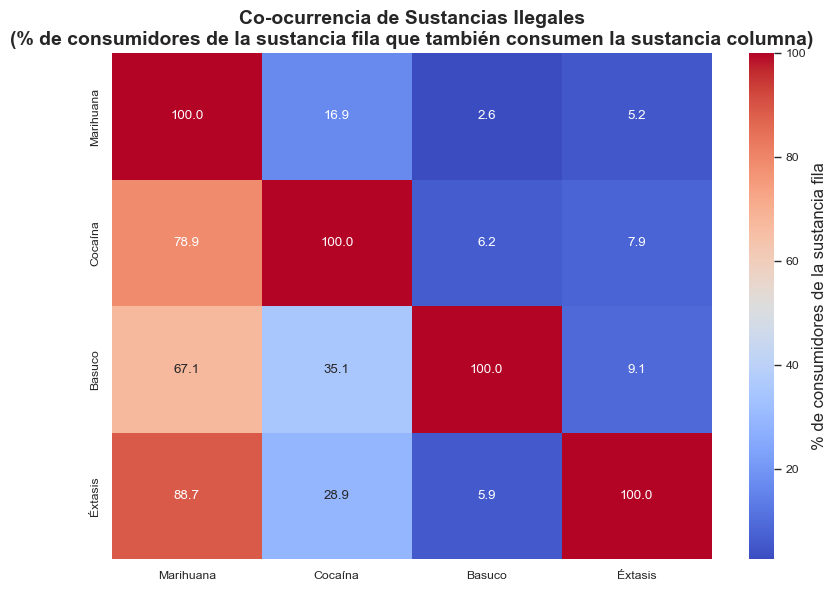

In [24]:
# Crear una matriz de co-ocurrencia ponderada.
# Filtramos a consumidores de al menos una sustancia para ver mejor los patrones.
df_consumidores = df[df['num_sustancias_ilegales'] > 0].copy()

if len(df_consumidores) > 0:
    # Crear matriz binaria (0/1) para las sustancias.
    sub_matrix = df_consumidores[sustancias].copy()
    # Renombrar columnas para mejores etiquetas en el mapa de calor.
    sub_matrix.columns = ['Marihuana', 'Cocaína', 'Basuco', 'Éxtasis']
    
    # Calcular co-ocurrencia ponderada.
    # Para simplificar, calculamos el porcentaje de consumidores de la sustancia A que también consumen B.
    subs = sub_matrix.columns
    cooc_matrix = pd.DataFrame(index=subs, columns=subs, dtype=float)
    
    for i, sub_i in enumerate(subs):
        for j, sub_j in enumerate(subs):
            # Población total ponderada que consume la sustancia i.
            total_i = df_consumidores.loc[sub_matrix[sub_i] == 1, 'fex_c'].sum()
            if total_i > 0:
                # Población ponderada que consume tanto i como j.
                ambas = df_consumidores.loc[(sub_matrix[sub_i] == 1) & (sub_matrix[sub_j] == 1), 'fex_c'].sum()
                cooc_matrix.loc[sub_i, sub_j] = (ambas / total_i) * 100
            else:
                cooc_matrix.loc[sub_i, sub_j] = np.nan

    plt.figure(figsize=(8, 6))
    sns.heatmap(cooc_matrix, annot=True, fmt='.1f', cmap='coolwarm', 
                cbar_kws={'label': '% de consumidores de la sustancia fila'})
    plt.title('Co-ocurrencia de Sustancias Ilegales\n(% de consumidores de la sustancia fila que también consumen la sustancia columna)', 
              fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "14_coocurrencia_sustancias.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No se encontraron consumidores de sustancias ilegales para el análisis de co-ocurrencia.")

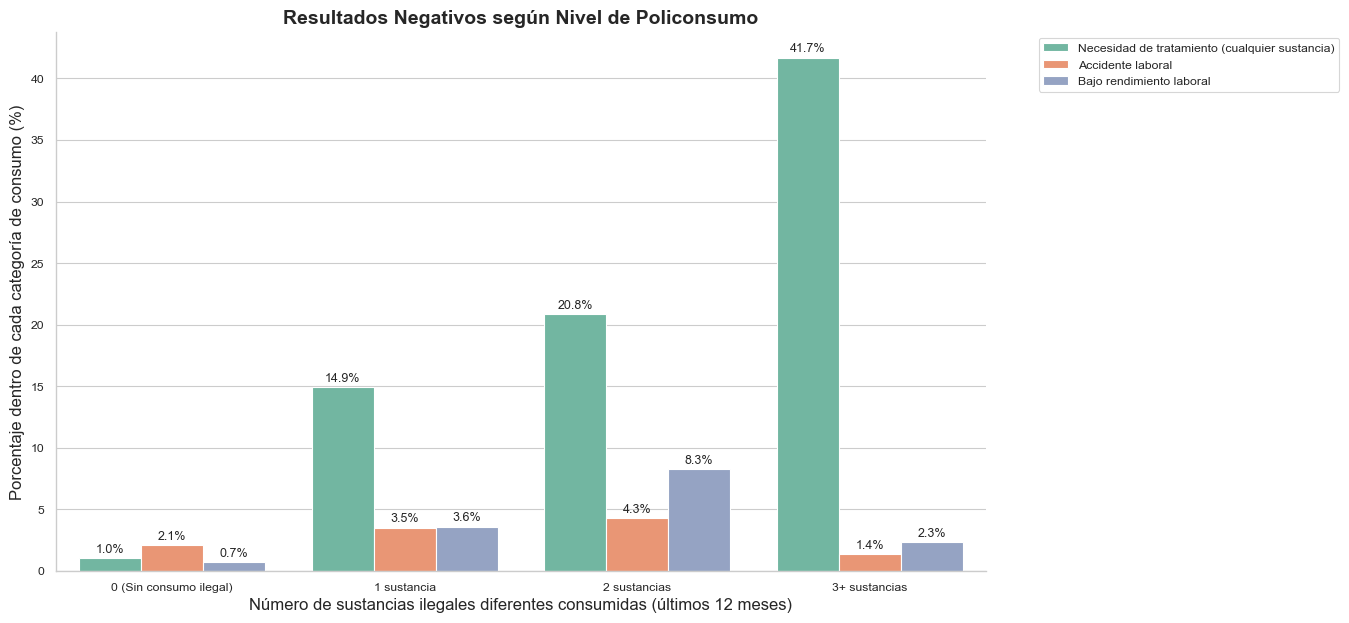

In [25]:
# Analizar si el policonsumo aumenta la probabilidad de resultados negativos.
columnas_resultados = {
    'Necesidad de tratamiento (cualquier sustancia)': (df['tratamiento_necesidad_tabaco'] == 1) | (df['tratamiento_necesidad_alcohol'] == 1) | (df['tratamiento_necesidad_otras'] == 1),
    'Accidente laboral': df['accidente_laboral'] == 1,
    'Bajo rendimiento laboral': df['bajo_rendimiento_laboral'] == 1
}

data_interseccion = []
for categoria in etiquetas:
    mask_cat = df['categoria_policonsumo'] == categoria
    total_cat_pop = df.loc[mask_cat, 'fex_c'].sum()
    
    if total_cat_pop == 0:
        continue
        
    fila = {'Categoria': categoria}
    for nombre_resultado, cond_resultado in columnas_resultados.items():
        mask_resultado = mask_cat & cond_resultado
        pop_resultado = df.loc[mask_resultado, 'fex_c'].sum()
        fila[nombre_resultado] = (pop_resultado / total_cat_pop) * 100
    data_interseccion.append(fila)

df_interseccion = pd.DataFrame(data_interseccion)

# Reorganizar para graficar.
df_interseccion_melted = df_interseccion.melt(id_vars='Categoria', var_name='Resultado', value_name='Porcentaje')

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_interseccion_melted, x='Categoria', y='Porcentaje', hue='Resultado', palette='Set2')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=9)

plt.title('Resultados Negativos según Nivel de Policonsumo', fontweight='bold')
plt.xlabel('Número de sustancias ilegales diferentes consumidas (últimos 12 meses)')
plt.ylabel('Porcentaje dentro de cada categoría de consumo (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()

plt.savefig(FIGURES_DIR / "15_policonsumo_vs_impactos.png", dpi=300, bbox_inches='tight')
plt.show()